In [11]:
import pandas as pd

# Charger le dataset du Titanic depuis l'URL
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
df = pd.read_csv(url)

# Afficher les 5 premières lignes pour vérifier que tout fonctionne
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [12]:
# 1. Pour voir le nombre de lignes, de colonnes et le type de données (ex: float, object...)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


In [13]:
# 2. Pour obtenir un résumé statistique automatique (Moyenne, Médiane/50%, Écart-type...) 
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [14]:
# 3. Pour voir exactement combien de valeurs manquantes (NaN) il y a dans chaque colonne
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [15]:
# Calculer la médiane de l'âge
age_median = df['age'].median()

# Remplir les valeurs manquantes dans la colonne 'age'
df['age'] = df['age'].fillna(age_median)

# Vérifier que la colonne 'age' n'a plus de valeurs manquantes
print("NAs restants pour l'âge :", df['age'].isnull().sum())

NAs restants pour l'âge : 0


In [16]:
# Remplacer le texte par des chiffres (mapping)
df['sex_encoded'] = df['sex'].map({'male': 1, 'female': 0})

# Afficher un aperçu pour vérifier
df[['sex', 'sex_encoded']].head()

,sex,sex_encoded
0,male,1
1,female,0
2,female,0
3,female,0
4,male,1


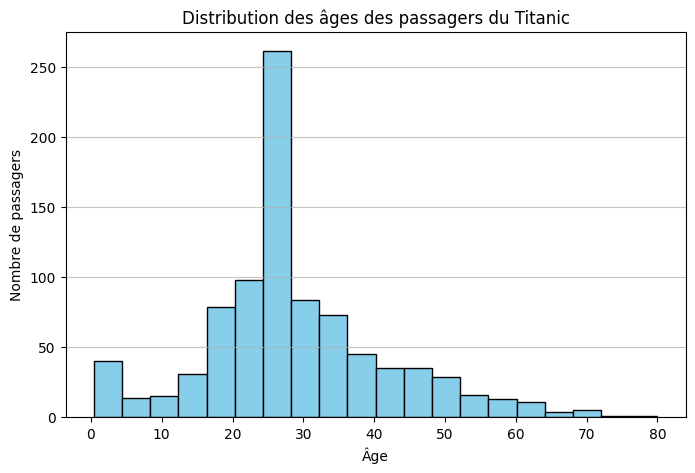

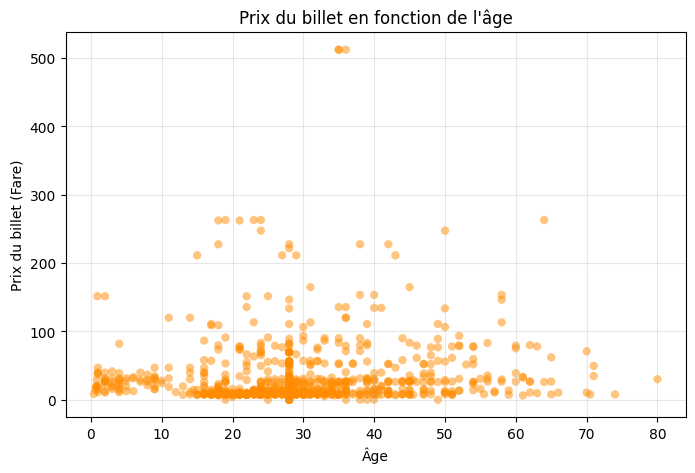

In [17]:
import matplotlib.pyplot as plt

# 1. Histogramme de l'âge des passagers
plt.figure(figsize=(8, 5))
plt.hist(df['age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution des âges des passagers du Titanic')
plt.xlabel('Âge')
plt.ylabel('Nombre de passagers')
plt.grid(axis='y', alpha=0.75)
plt.savefig('histogram_age.png')  # Sauvegarde automatique en PNG
plt.show()

# 2. Scatter plot (Nuage de points) : Prix du billet (Fare) vs Âge
plt.figure(figsize=(8, 5))
plt.scatter(df['age'], df['fare'], alpha=0.5, color='darkorange', edgecolor='none')
plt.title('Prix du billet en fonction de l\'âge')
plt.xlabel('Âge')
plt.ylabel('Prix du billet (Fare)')
plt.grid(True, alpha=0.3)
plt.savefig('scatter_fare_vs_age.png')  # Sauvegarde automatique en PNG
plt.show()